Purpose: URL is Legitimate or Phising?

In [89]:
#Import necessary libraries with aliases
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


In [90]:
df = pd.read_csv("Phishing_URL_ds_5percent_missing_train.csv")
df.shape

(156808, 56)

Comment: Train Data has 156808 number of URL instances.

In [91]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,mw15752.txt,http://www.oshgiutz.cf,21.0,www.oshgiutz.cf,15.0,0.0,cf,54.545455,1.0000,0.000186,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,mw106505.txt,http://www.mimosdachika.com.br,29.0,www.mimosdachika.com.br,23.0,0.0,br,74.792244,0.8125,0.009442,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,472706.txt,https://www.claddaghrings.com,28.0,www.claddaghrings.com,21.0,0.0,com,100.000000,1.0000,0.522907,...,1.0,0.0,NaN,44.0,4.0,NaN,48.0,0.0,50.0,1.0
3,mw1272.txt,http://www.mnbvcxzzz12.com,25.0,www.mnbvcxzzz12.com,NaN,0.0,com,54.444444,1.0000,0.522907,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,739855.txt,https://www.fulhamsupporterstrust.com,36.0,www.fulhamsupporterstrust.com,29.0,0.0,com,100.000000,1.0000,0.522907,...,0.0,0.0,1.0,16.0,4.0,7.0,55.0,3.0,55.0,1.0


Comments: Data looks like clean in general.FILENAME seems unnecesarry column for our model. Looking more closely to data for missing data and datatypes.

In [92]:
#Removing FILENAME column, looking informations about columns
df = df.drop(df.columns[0], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156808 entries, 0 to 156807
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         148878 non-null  object 
 1   URLLength                   149003 non-null  float64
 2   Domain                      149046 non-null  object 
 3   DomainLength                148895 non-null  float64
 4   IsDomainIP                  148814 non-null  float64
 5   TLD                         148990 non-null  object 
 6   URLSimilarityIndex          148967 non-null  float64
 7   CharContinuationRate        148904 non-null  float64
 8   TLDLegitimateProb           148935 non-null  float64
 9   URLCharProb                 149009 non-null  float64
 10  TLDLength                   148893 non-null  float64
 11  NoOfSubDomain               148978 non-null  float64
 12  HasObfuscation              148998 non-null  float64
 13  NoOfObfuscated

Comment: Column names seems consistent. We create missingness in data, as we can see there are missing values with different numbers in columns. Data types seems consistent with column meanings in general, there is no problem. For columns which have binary values should converted to the int data type. Reason behin this is mathematical rules, for library conformity in scikit-learn, and memory efficiency. Label is also should be converted. 

In [93]:
#Convert binary columns data type as int8/bool--bunu imputationdan sonra yapmalıyız. 

# #All features with numeric data types
# numeric_df = df.select_dtypes(include=['float64'])

# #Features have exactly 2 unique variables
# binary_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() == 2]

# #Features have more than 2 unique variables are not binary
# continuous_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() > 2]

# print(f"Binary Feature Number: {len(binary_cols)}")
# print(f"Continous Feature Number: {len(continuous_cols)}")
# df[binary_cols] = df[binary_cols].astype('Int8')
# df.info()

In [94]:
#Checking duplicates
df[df.duplicated()]

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label


Comments: We have no duplicated observations. There is no problem. 

In [95]:
#Looking identical URLs
url_counts = df['URL'].value_counts()
print(url_counts)

URL
http://www.sbi.mx/page/41/786/m.php           2
https://amfcu5x.firebaseapp.com/              2
https://andesfitness.cl/img/tufu.html         2
http://hg44788.com/                           2
https://uniswap.v2.testnet.pulsechain.com/    2
                                             ..
https://www.alaskavisit.com                   1
https://www.thomasmcandrew.com                1
https://www.smtd.jp.harvemart.cc              1
https://www.nylas.com                         1
https://www.fnal.gov                          1
Name: count, Length: 148709, dtype: int64


In [96]:
#Looking same url count number
print(len(url_counts[url_counts > 1]))

169


Comment: We have 169 URL names that seen twice in our dataset. This may cause data leakage. First question that comes to my mind is same url names have same label value?

In [97]:
#Looking url's with corresponding labels
inconsistent = df.groupby('URL')['label'].nunique()
print(inconsistent[inconsistent > 1])

Series([], Name: label, dtype: int64)


Comment: Although the URL names were the same, these URLs were not perceived differently as either phishing or legitimate. To avoid data leakage we remove same URL rows -> 169 rows from our dataset, other 169 with same value still in the dataset to use this informations in our model.

In [98]:
#Remove same url rows
df = df.drop_duplicates(subset=['URL'], keep='first')

#Test whether duplicate url's gone.
url_counts = df['URL'].value_counts()
print(len(url_counts[url_counts > 1]))

0


In [99]:
#Other Strings data cleaning
string_df = df.select_dtypes(include=['object']).columns
print(string_df)
print(df['Domain'].value_counts())

Index(['URL', 'Domain', 'TLD', 'Title'], dtype='object')
Domain
ipfs.io                         736
docs.google.com                 290
cloudflare-ipfs.com             220
mail.deliverylifesupport.com    208
storageapi.fleek.co             197
                               ... 
hvc3xj2uqd.web.app                1
www.houseofbotori.com             1
yahoo-106204.weeblysite.com       1
www.dhasselhoff.net               1
www.markenmagazin.de              1
Name: count, Length: 133555, dtype: int64


Comment: We examine that normally url domains starts with www, but phising sites may use this domain not inclued subdomain. We look this is true or not?

Question: "Bir alan adının (domain) 'www' önekiyle başlaması ile o sitenin Phishing (0) veya Legitimate (1) olması arasında istatistiksel olarak anlamlı bir ilişki var mıdır?"

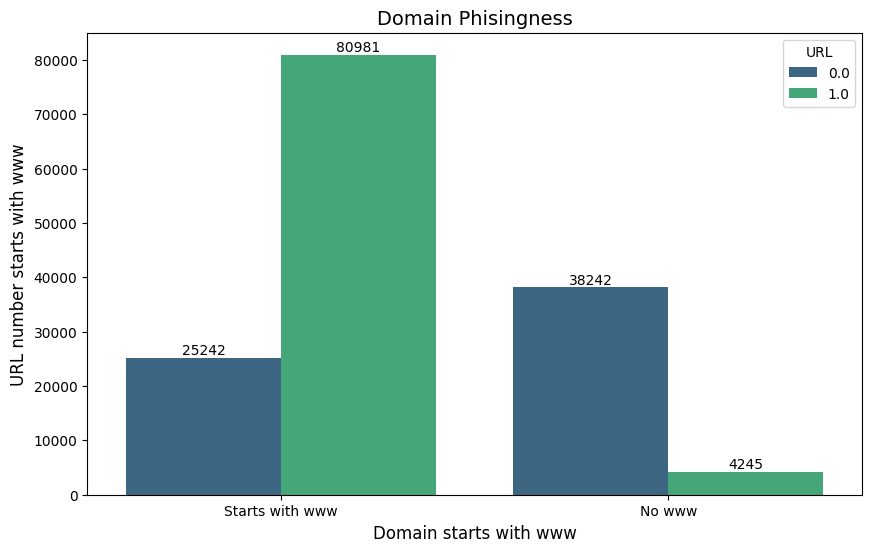

In [100]:
#Creating new column domain starts with www
df['starts_with_www'] = df['Domain'].astype(str).str.startswith('www').map({True: 'Starts with www', False: 'No www'})
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='starts_with_www', hue='label', palette='viridis')
plt.title('Domain Phisingness', fontsize=14)
plt.xlabel('Domain starts with www', fontsize=12)
plt.ylabel('URL number starts with www', fontsize=12)
plt.legend(title='URL')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [101]:
#Statistical Test-Contingency Table

contingency_table = pd.crosstab(df['starts_with_www'], df['label'])
print("Gözlemlenen Değerler Tablosu:\n", contingency_table)

# Testi uygula
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nP-Value Değeri: {p:.5f}")
if p < 0.05:
    print("SONUÇ: H0 Reddedildi. İki değişken arasında ANLAMLI bir ilişki var.")
    print("Yorum: 'www' kullanımı, sitenin phishing olup olmadığı hakkında bilgi veriyor.")
else:
    print("SONUÇ: H0 Reddedilemedi. İlişki anlamsız.")
    print("Yorum: 'www' olup olmaması ayırt edici bir özellik değil.")

# Temizlik: Geçici sütunları silelim
df.drop(columns=['starts_with_www'], inplace=True)


Gözlemlenen Değerler Tablosu:
 label              0.0    1.0
starts_with_www              
No www           38242   4245
Starts with www  25242  80981

P-Value Değeri: 0.00000
SONUÇ: H0 Reddedildi. İki değişken arasında ANLAMLI bir ilişki var.
Yorum: 'www' kullanımı, sitenin phishing olup olmadığı hakkında bilgi veriyor.


In [102]:
counts = df['Title'].value_counts()
print(counts)

Title
0                              19598
#name?                            11
gov                                8
info-update-sucreeblogspot         7
65gfgfgfgfg4g4gblogspot?m=1        6
                               ...  
loomio                             1
meta-suppoort-2023start            1
blackrockresort                    1
fivefilters                        1
ziapy                              1
Name: count, Length: 119895, dtype: int64


Comments: 0 values are missing values. We want to research that, rows that has missing value in title column are more phising or just random?

In [103]:
#Cleaning for title
garbage_list = ['0', 0, '#name?', 'nan', 'Null', '']
df['Title'] = df['Title'].replace(garbage_list, np.nan)

#Research Question
print(df[df['Title'].isna()]['label'].value_counts(normalize=True))

label
0.0    0.841477
1.0    0.158523
Name: proportion, dtype: float64


Comment: Yes! There seems a pattern. Title olmayanların yüzde 85'i phising oluyor. For feature engineering and solve high cardinality problem, and for use this title column effiecently we convert this column to is_title_empty column. This explains the phising mechanism.

In [104]:
#Feature Engineering for Title Column
df['is_title_empty'] = df['Title'].isna().astype('int8')
df = df.drop(columns=['Title'])
print(df[['is_title_empty']].head())

   is_title_empty
0               0
1               1
2               0
3               1
4               0


EDA

In [105]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Test 1: Using ONLY is_title_empty
X_simple = df[['is_title_empty']]
y = df['label']

clf = DecisionTreeClassifier(max_depth=2) # Very simple model
clf.fit(X_simple, y)
print(f"Accuracy with ONLY is_title_empty: {accuracy_score(y, clf.predict(X_simple)):.4f}")

Accuracy with ONLY is_title_empty: 0.6967


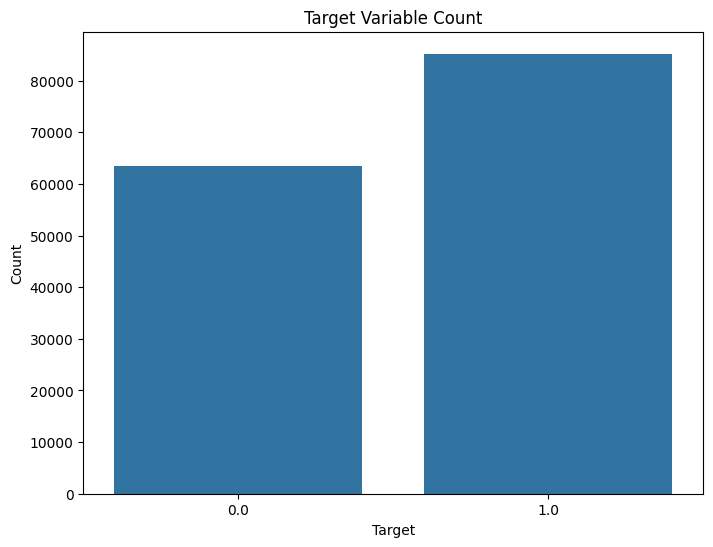

In [106]:
#Looking number of target variables. This is important for our problem. In real life most of the URL's are legitimate. 
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x=df["label"])
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Target Variable Count')
plt.show()

Comment: We see that the target variable counts are close to each other, a little bit imbalanced problem we deal with this. But as in real life scenario 0 (legitimate url) count is more than phising URL values. This dataset can gives us more information about phising urls. 

Firsly, we want to look at the correlation matrix in order to look at the which features have most effect on target variable. 

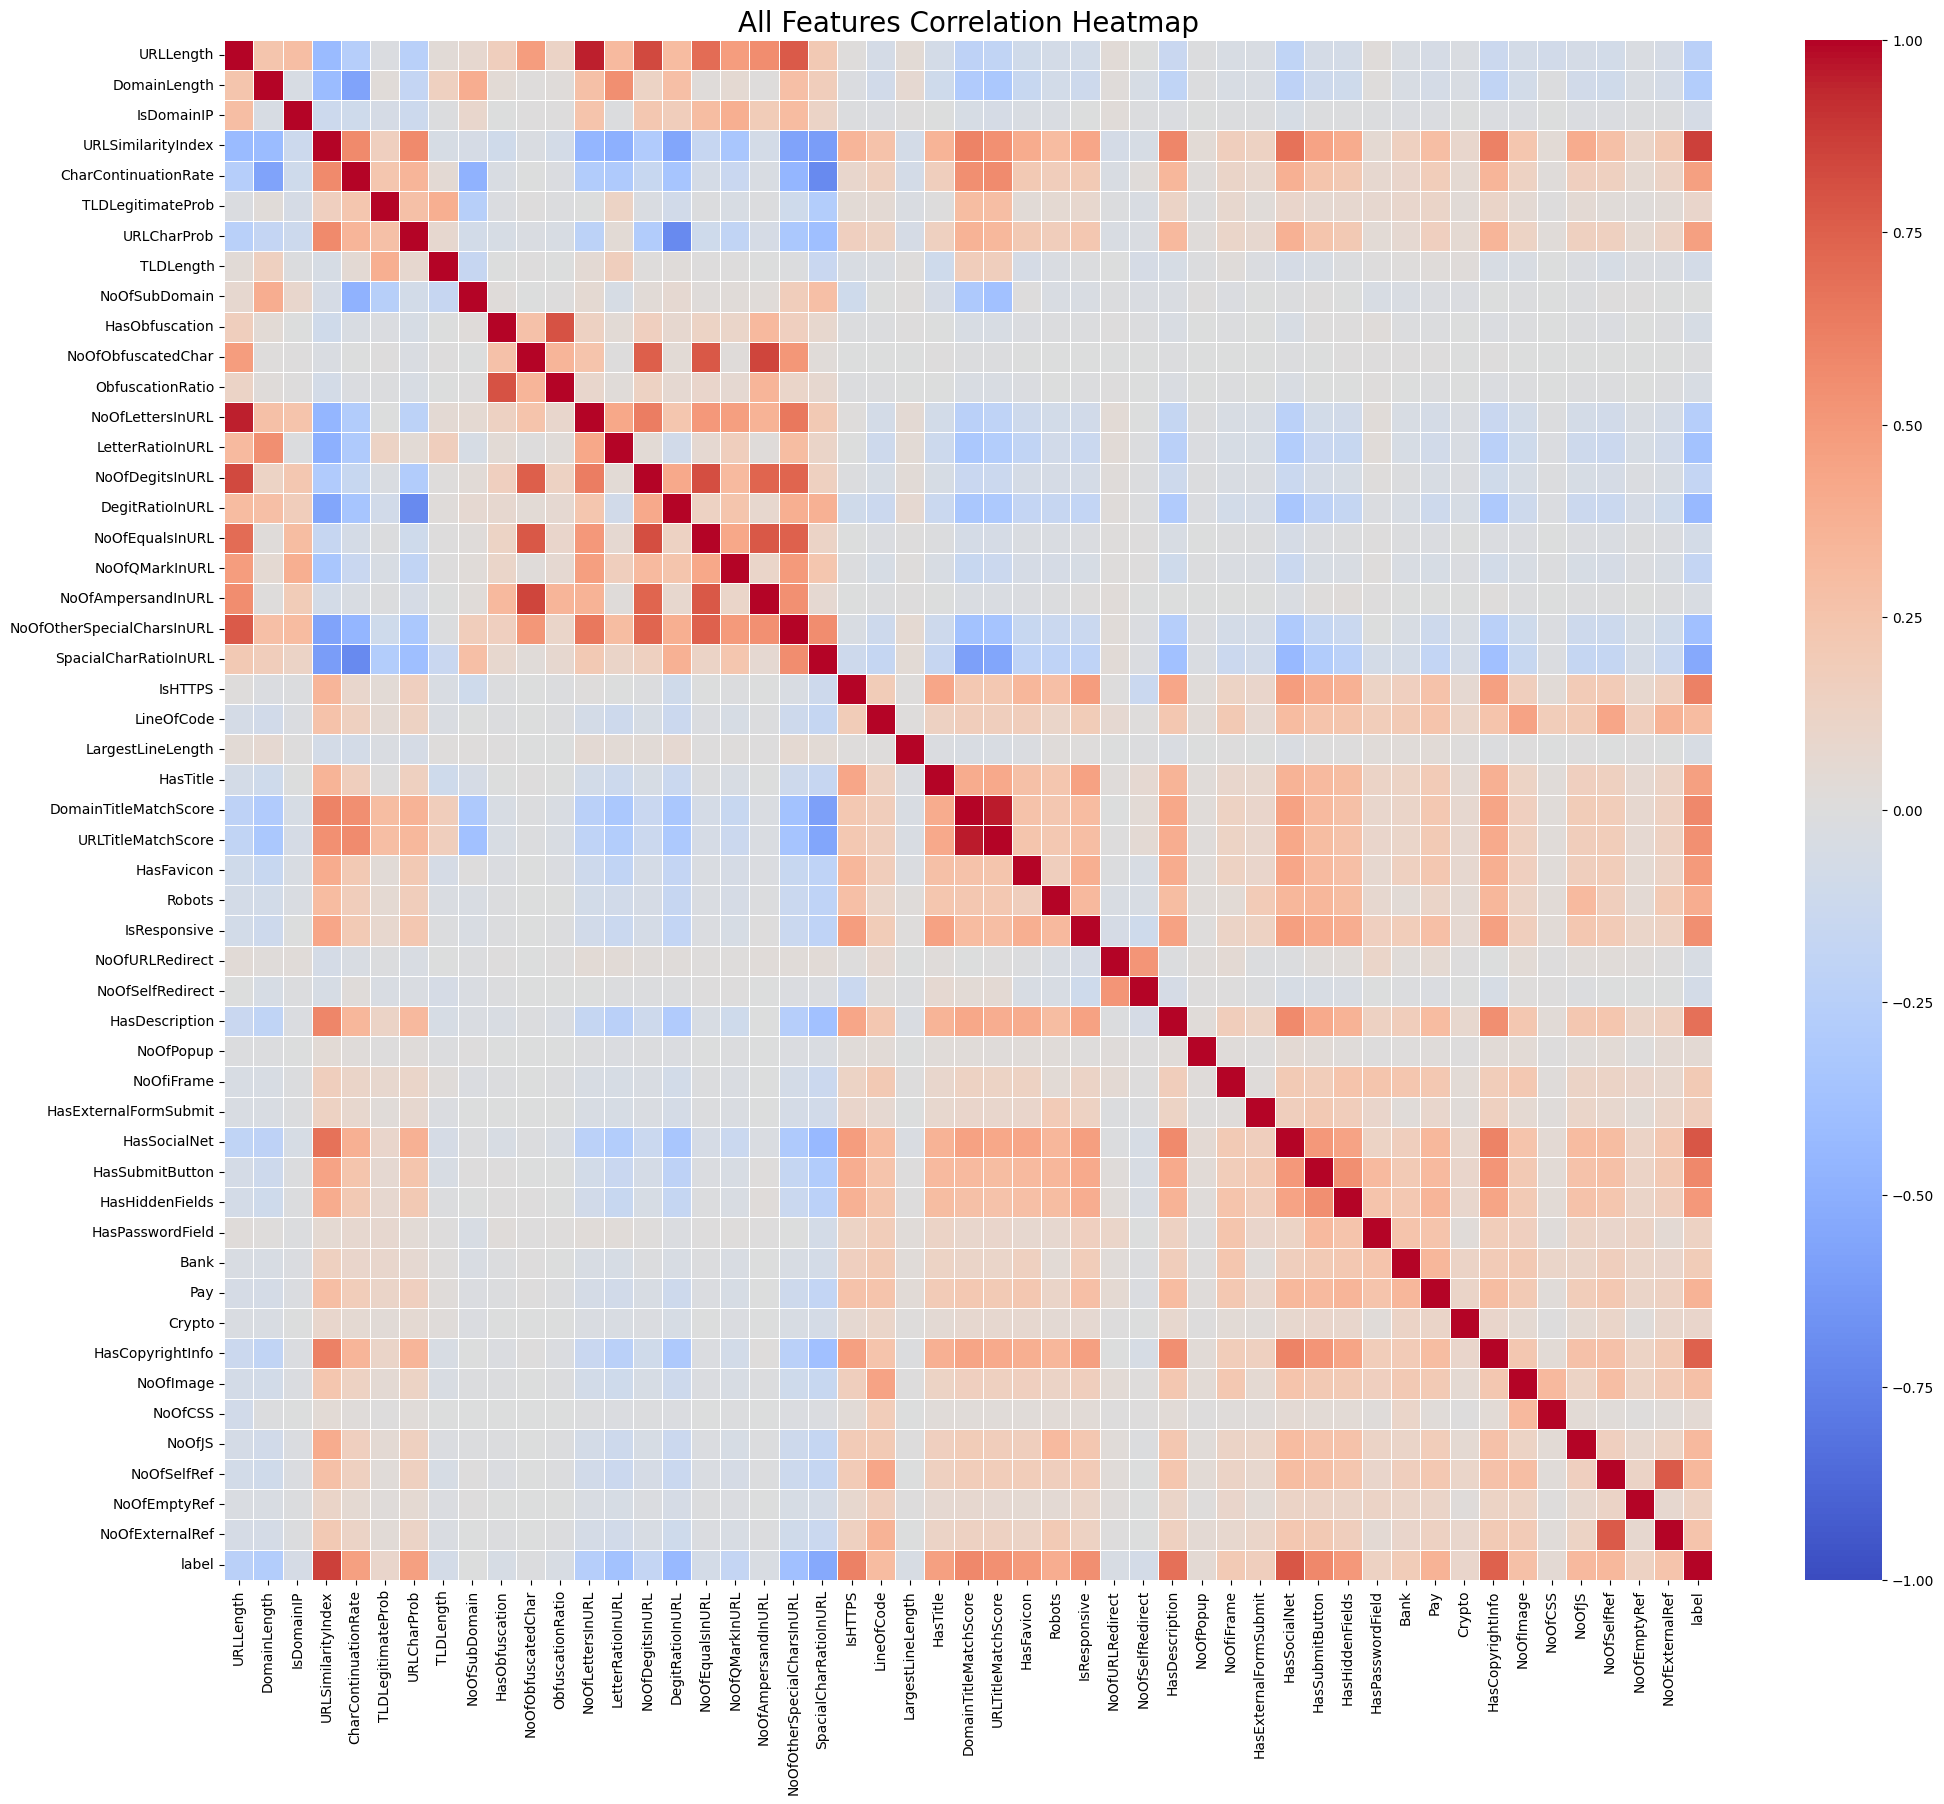

In [107]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(24, 20)) 
sns.heatmap(corr_matrix, 
            annot=False,      
            cmap='coolwarm',  # (Red: Positive, Blue: Negative)
            linewidths=0.5,   
            vmin=-1, vmax=1)

plt.title('All Features Correlation Heatmap', fontsize=20)
plt.show()

Comments: Strong correlation between features can be handle in feature enginerring part. Firstly, we want to look at closely on which features have effect on our target variable. We see this information on heatmap but we want to look closely.  

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17976\2732559188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)


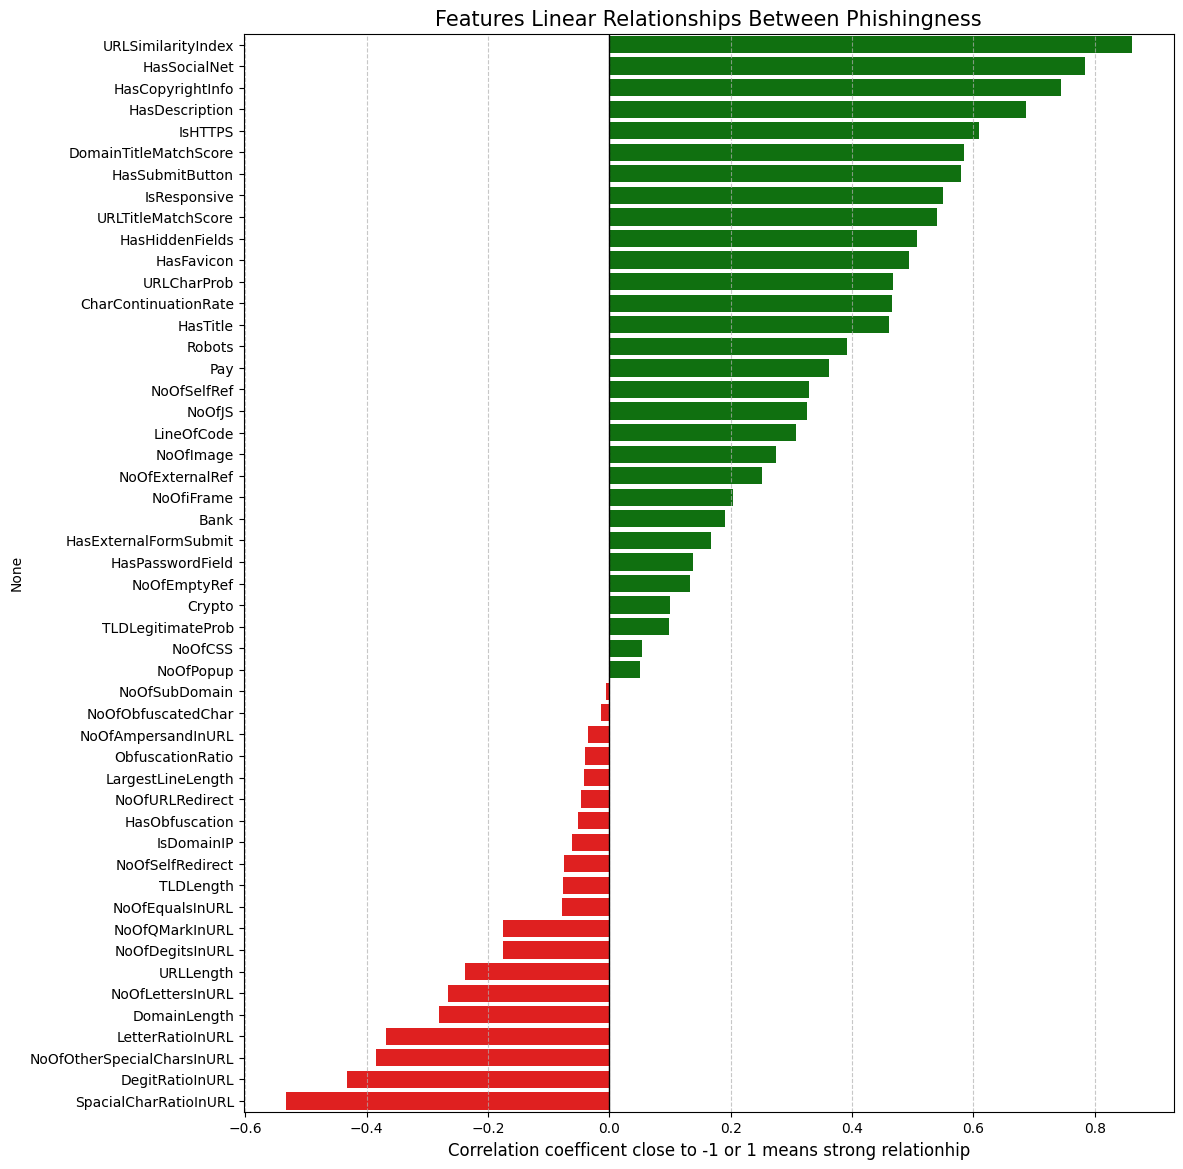

In [108]:
target_corr = numeric_df.corr()['label'].sort_values(ascending=False)
target_corr = target_corr.drop('label')
plt.figure(figsize=(12, 14))
colors = ['green' if x > 0 else 'red' for x in target_corr.values] # (Green:Positive, Red: Negative)
sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)

plt.title('Features Linear Relationships Between Phishingness', fontsize=15)
plt.xlabel('Correlation coefficent close to -1 or 1 means strong relationhip', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Black line in the middle
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Comment: Features that are close to 0 correlation coefficents indicates pottential features that we must deal with maybe we extract these from the model because they have not strong effect on target variable and adds complexity for our model. Strong relationships can be our focus features in the analysis. 

We examine that the some float and integer data types are binary variables. Firstly, we can seperate these variables and then we can see the the selected features which are seem more correlated with our target variable.